# comparetest

Exploratory notebook for comparing detections from two views of the same night:

- Arducam blobs from `06_arducam_video_analysis_nov12.ipynb`
- Star-trails contours from `02_video_analysis_nov12.ipynb`

## What this notebook loads

Expected source files:
- `data/processed/blobs_12nov2025_phys.csv`
- `data/processed/GX010067_2025Nov12_streaks.csv`

The raw contour CSV has a short metadata preamble before the detection table, so the loader below skips that header block.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'processed'
FIGURES_DIR = ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

arducam_csv = DATA_DIR / 'blobs_12nov2025_phys.csv'
streak_csv = DATA_DIR / 'GX010067_2025Nov12_streaks.csv'

print('ROOT =', ROOT)
print('Arducam CSV =', arducam_csv)
print('Contour CSV =', streak_csv)

ROOT = /Users/oakley/Documents/GitHub/signal_respirometry
Arducam CSV = /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/blobs_12nov2025_phys.csv
Contour CSV = /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010067_2025Nov12_streaks.csv


In [47]:
import re

def load_arducam_blobs(
    path: Path,
    arducam_fps: float = 10.0,
    arducam_part_duration_s: float | None = None,
    use_detected_part_durations: bool = True,
 ) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df.copy()
    df['source'] = 'arducam_blobs'
    df['x'] = df['x'].astype(float)
    df['y'] = df['y'].astype(float)

    # Use frame/fps for local time when frame is available (preferred).
    if 'frame' in df.columns:
        df['time_s_local'] = df['frame'].astype(float) / arducam_fps
    else:
        df['time_s_local'] = df['t_sec'].astype(float)

    # Build cumulative time across Arducam part files (part1, part2, ...).
    # We now prefer per-part durations derived from detected t_sec maxima.
    # This avoids the old fixed-300s assumption that compressed the full-night timeline.
    def extract_part_num(name: str) -> int:
        m = re.search(r'_part(\d+)\.mp4$', str(name))
        return int(m.group(1)) if m else 10**9

    df['part_num'] = df['video_name'].map(extract_part_num)
    min_part = int(df['part_num'].min())
    part_order = sorted(df['part_num'].dropna().unique().tolist())

    frame_dt = 1.0 / float(arducam_fps) if arducam_fps else 0.0
    part_offset_map = {}
    cumulative_offset = 0.0

    if use_detected_part_durations and 't_sec' in df.columns:
        per_part_duration = (
            df.groupby('part_num')['t_sec']
            .max()
            .sort_index()
        )
        duration_mode = 'detected_tsec_max'
        for p in part_order:
            part_offset_map[p] = cumulative_offset
            dur = float(per_part_duration.get(p, np.nan))
            if not np.isfinite(dur):
                dur = float(arducam_part_duration_s) if arducam_part_duration_s is not None else 0.0
            # Add one frame so adjacent parts do not overlap at boundaries.
            cumulative_offset += dur + frame_dt
    else:
        if arducam_part_duration_s is None:
            raise ValueError(
                'Need arducam_part_duration_s when use_detected_part_durations=False '
                'or when t_sec is unavailable.'
            )
        duration_mode = 'fixed_part_duration'
        for p in part_order:
            part_offset_map[p] = cumulative_offset
            cumulative_offset += float(arducam_part_duration_s)

    df['part_offset_s'] = df['part_num'].map(part_offset_map).astype(float)
    df['time_s'] = df['time_s_local'] + df['part_offset_s']

    # Keep diagnostics available for later inspection in the notebook.
    df.attrs['arducam_fps'] = arducam_fps
    df.attrs['arducam_part_duration_s'] = arducam_part_duration_s
    df.attrs['arducam_duration_mode'] = duration_mode
    df.attrs['min_part'] = min_part
    df.attrs['n_parts'] = len(part_order)
    return df

def load_star_trails_contours(path: Path) -> pd.DataFrame:
    # The raw contour CSV has a three-line metadata preamble:
    # 1) metadata header
    # 2) metadata row with video info
    # 3) blank line
    # The detection table starts on line 4.
    df = pd.read_csv(path, skiprows=3)
    df = df.copy()
    df['source'] = 'star_trails_contours'
    df['time_s'] = df['time_s'].astype(float)
    df['x'] = df['cx'].astype(float)
    df['y'] = df['cy'].astype(float)
    return df

def estimate_gopro_lights_off_s(
    df: pd.DataFrame,
    bin_size_s: float = 30.0,
    smooth_bins: int = 5,
    search_max_s: float | None = 5400.0,
 ) -> tuple[float, float]:
    # Heuristic: lights-off appears as a sharp sustained drop in detections.
    t = df['time_s'].dropna().to_numpy(dtype=float)
    if len(t) < 20:
        return np.nan, np.nan

    if search_max_s is not None:
        t = t[t <= float(search_max_s)]
        if len(t) < 20:
            return np.nan, np.nan

    start = np.floor(t.min() / bin_size_s) * bin_size_s
    stop = np.ceil(t.max() / bin_size_s) * bin_size_s + bin_size_s
    edges = np.arange(start, stop + bin_size_s, bin_size_s)
    counts, _ = np.histogram(t, bins=edges)
    centers = edges[:-1] + bin_size_s / 2.0

    smooth = pd.Series(counts.astype(float)).rolling(
        window=smooth_bins, center=True, min_periods=1
    ).mean().to_numpy()
    drop = np.diff(smooth, prepend=smooth[0])
    idx = int(np.argmin(drop))
    return float(centers[idx]), float(drop[idx])

# Timing settings.
# Arducam FPS is now treated as known/fixed from acquisition metadata + CSV sanity check.
arducam_fps_known = 10.0
arducam_use_detected_part_durations = True
arducam_part_duration_fallback_s = 1930.7

# Colleague metadata: GoPro time-lapse sampled at 0.03333 fps (about one frame every 30 s).
gopro_sampling_fps = 0.03333
gopro_sampling_interval_s = 1.0 / gopro_sampling_fps

# Arducam lights-off options, priority:
# 1) explicit manual seconds
# 2) near-start rule (for multi-part analyses where the true first lights-on segment may be absent)
# 3) fixed fallback from blackdetect
arducam_lights_off_s_manual = None
use_arducam_near_start_lights_off = True
arducam_near_start_offset_s = 1.0
arducam_blackdetect_lights_off_s_fallback = 1930.7

# GoPro lights-off options, priority:
# 1) explicit manual seconds
# 2) near-start rule (for "only a few bright frames" videos)
# 3) auto-estimated drop
gopro_lights_off_s_manual = None
use_gopro_near_start_lights_off = True
gopro_near_start_offset_frames = 1
gopro_near_start_offset_s = gopro_near_start_offset_frames * gopro_sampling_interval_s

auto_estimate_gopro_lights_off = False
gopro_estimate_bin_s = 30.0
gopro_estimate_smooth_bins = 5
gopro_estimate_search_max_s = 5400.0

arducam_df = load_arducam_blobs(
    arducam_csv,
    arducam_fps=arducam_fps_known,
    arducam_part_duration_s=arducam_part_duration_fallback_s,
    use_detected_part_durations=arducam_use_detected_part_durations,
 )
contour_df = load_star_trails_contours(streak_csv)

arducam_anchor_source = 'manual'
if arducam_lights_off_s_manual is not None:
    arducam_lights_off_s = float(arducam_lights_off_s_manual)
elif use_arducam_near_start_lights_off:
    arducam_lights_off_s = float(arducam_df['time_s'].min()) + float(arducam_near_start_offset_s)
    arducam_anchor_source = 'near_start_rule'
else:
    arducam_lights_off_s = float(arducam_blackdetect_lights_off_s_fallback)
    arducam_anchor_source = 'blackdetect_fallback'

gopro_anchor_source = 'manual'
gopro_anchor_drop_score = np.nan
if gopro_lights_off_s_manual is not None:
    gopro_lights_off_s = float(gopro_lights_off_s_manual)
elif use_gopro_near_start_lights_off:
    gopro_lights_off_s = float(contour_df['time_s'].min()) + float(gopro_near_start_offset_s)
    gopro_anchor_source = 'near_start_rule'
elif auto_estimate_gopro_lights_off:
    gopro_lights_off_s, gopro_anchor_drop_score = estimate_gopro_lights_off_s(
        contour_df,
        bin_size_s=gopro_estimate_bin_s,
        smooth_bins=gopro_estimate_smooth_bins,
        search_max_s=gopro_estimate_search_max_s,
    )
    gopro_anchor_source = 'auto_estimated_early_window'
else:
    gopro_lights_off_s = None
    gopro_anchor_source = 'unset'

# Discard Arducam detections from pre-courtship / pre-lights-off period.
use_lights_off_filter = True
arducam_courtship_start_s = 1200.0
arducam_min_keep_time_s = max(
    arducam_courtship_start_s,
    arducam_lights_off_s if use_lights_off_filter else -np.inf,
 )

before_arducam_time_filter = len(arducam_df)
arducam_df = arducam_df[arducam_df['time_s'] >= arducam_min_keep_time_s].copy()
discarded_arducam_pre_time = before_arducam_time_filter - len(arducam_df)

# When force-anchoring by lights-out, keep GoPro at or after lights-off only.
use_gopro_lights_off_filter = gopro_lights_off_s is not None
before_gopro_time_filter = len(contour_df)
if use_gopro_lights_off_filter:
    contour_df = contour_df[contour_df['time_s'] >= float(gopro_lights_off_s)].copy()
discarded_gopro_pre_time = before_gopro_time_filter - len(contour_df)

# Remove near-constant nuisance lights (hotspots) in Arducam view.
# Each tuple is (x_min, x_max, y_min, y_max).
exclude_static_lights = True
hotspot_windows = [
    (80.0, 220.0, 640.0, 760.0),      # user-observed early hotspot around x~100-200, y~700
    (1520.0, 1600.0, 960.0, 1040.0),  # dominant persistent hotspot found after first-pass filtering
]

before_hotspot_filter = len(arducam_df)
if exclude_static_lights:
    hotspot_mask = pd.Series(False, index=arducam_df.index)
    for x_min, x_max, y_min, y_max in hotspot_windows:
        hotspot_mask |= (
            arducam_df['x'].between(x_min, x_max)
            & arducam_df['y'].between(y_min, y_max)
        )
    arducam_df = arducam_df.loc[~hotspot_mask].copy()
    discarded_hotspot = int(hotspot_mask.sum())
else:
    discarded_hotspot = 0

comparison_df = pd.concat([
    arducam_df.assign(view='arducam'),
    contour_df.assign(view='star_trails'),
] , ignore_index=True, sort=False)

loader_preview = load_arducam_blobs(
    arducam_csv,
    arducam_fps=arducam_fps_known,
    arducam_part_duration_s=arducam_part_duration_fallback_s,
    use_detected_part_durations=arducam_use_detected_part_durations,
 )
gopro_dt = np.sort(contour_df['time_s'].dropna().unique())
if len(gopro_dt) > 1:
    gopro_median_step_s = float(np.median(np.diff(gopro_dt)))
else:
    gopro_median_step_s = np.nan

print(f"Arducam FPS fixed: {loader_preview.attrs['arducam_fps']:.1f}")
print(f"Arducam duration mode: {loader_preview.attrs['arducam_duration_mode']}")
print(f"Arducam fallback part duration (if needed): {arducam_part_duration_fallback_s:.1f} s")
print(f"GoPro timelapse sampling: {gopro_sampling_fps:.5f} fps (~{gopro_sampling_interval_s:.2f} s/frame)")
if np.isfinite(gopro_median_step_s):
    print(f"Observed median GoPro time step in contours: {gopro_median_step_s:.2f} s")
print(f'Arducam detections (raw): {before_arducam_time_filter} rows')
print(f'Arducam lights-off anchor ({arducam_anchor_source}): {arducam_lights_off_s}')
print(f'  arducam near-start offset: {arducam_near_start_offset_s:.3f} s')
print(f'Applied minimum Arducam keep time: {arducam_min_keep_time_s:.1f} s')
print(
    f"  (courtship_start={arducam_courtship_start_s:.1f} s, "
    f"use_lights_off_filter={use_lights_off_filter})"
 )
print(f'Discarded pre-time-threshold Arducam detections: {discarded_arducam_pre_time} rows')
print(f'GoPro detections (raw): {before_gopro_time_filter} rows')
print(f'GoPro lights-off anchor ({gopro_anchor_source}): {gopro_lights_off_s}')
print(f'  near-start offset: {gopro_near_start_offset_s:.2f} s ({gopro_near_start_offset_frames} frame)')
if np.isfinite(gopro_anchor_drop_score):
    print(f'  auto-estimate search_max_s: {gopro_estimate_search_max_s}')
    print(f'  auto-estimate drop score: {gopro_anchor_drop_score:.3f}')
print(f'Applied GoPro lights-off filter: {use_gopro_lights_off_filter}')
print(f'Discarded pre-time-threshold GoPro detections: {discarded_gopro_pre_time} rows')
print(f'Arducam detections after time filter: {before_hotspot_filter} rows')
print(f'Discarded static-light hotspot detections: {discarded_hotspot} rows')
print('Hotspot windows used:')
for x_min, x_max, y_min, y_max in hotspot_windows:
    print(f'  x in [{x_min:.0f}, {x_max:.0f}], y in [{y_min:.0f}, {y_max:.0f}]')
print(
    f"Arducam cumulative time span kept: {arducam_df['time_s'].min() / 3600:.2f} to "
    f"{arducam_df['time_s'].max() / 3600:.2f} h"
 )
print(f'Kept Arducam detections for alignment: {len(arducam_df)} rows')
print(f'Kept GoPro detections for alignment: {len(contour_df)} rows')
print(f'Combined comparison table: {len(comparison_df)} rows')

Arducam FPS fixed: 10.0
Arducam duration mode: detected_tsec_max
Arducam fallback part duration (if needed): 1930.7 s
GoPro timelapse sampling: 0.03333 fps (~30.00 s/frame)
Observed median GoPro time step in contours: 30.00 s
Arducam detections (raw): 6265 rows
Arducam lights-off anchor (near_start_rule): 27.6
  arducam near-start offset: 1.000 s
Applied minimum Arducam keep time: 1200.0 s
  (courtship_start=1200.0 s, use_lights_off_filter=True)
Discarded pre-time-threshold Arducam detections: 112 rows
GoPro detections (raw): 8428 rows
GoPro lights-off anchor (near_start_rule): 360.00300030003
  near-start offset: 30.00 s (1 frame)
Applied GoPro lights-off filter: True
Discarded pre-time-threshold GoPro detections: 5 rows
Arducam detections after time filter: 6153 rows
Discarded static-light hotspot detections: 2448 rows
Hotspot windows used:
  x in [80, 220], y in [640, 760]
  x in [1520, 1600], y in [960, 1040]
Arducam cumulative time span kept: 0.37 to 11.67 h
Kept Arducam detection

## Time alignment and shared axis exploration

This section bins detections from both views into a common time grid, searches for the lag that best aligns the activity envelopes, and then plots both views on one time axis so you can judge how well they correlate.

Alignment summary
Bin size: 60 s
Lag selection metric: strict_lights_out_anchor_refined(+/-2 min)
force_lights_out_anchor = True
lock_to_anchor_exact = False
arducam_lights_off_s = 27.6
gopro_lights_off_s = 360.00300030003
Anchor lag from lights-out: -332 s (-5.5 min)
Best lag after local refinement: -480 s (-8.0 min)
Lag-correlation (full grid at best lag): 0.128
Lag-correlation (active-overlap at best lag): 0.162 (n_active_bins=93)
Overlap window (Arducam active): 0.38 to 11.68 h; normalized correlation = -0.020


,lag_steps,correlation_full,correlation_active,n_active_bins
0,-8,0.128461,0.161526,93
1,-7,0.095203,0.069612,93
4,-4,0.078835,0.005270,93
2,-6,0.075757,-0.000516,93
3,-5,0.071311,-0.018120,93


,time_aligned_s,arducam_count,star_trails_count
0,870.0,0.0,3.0
1,930.0,0.0,8.0
2,990.0,0.0,9.0
3,1050.0,0.0,10.0
4,1110.0,0.0,11.0
5,1170.0,0.0,12.0
6,1230.0,0.0,12.0
7,1290.0,0.0,12.0
8,1350.0,71.0,12.0
9,1410.0,0.0,12.0


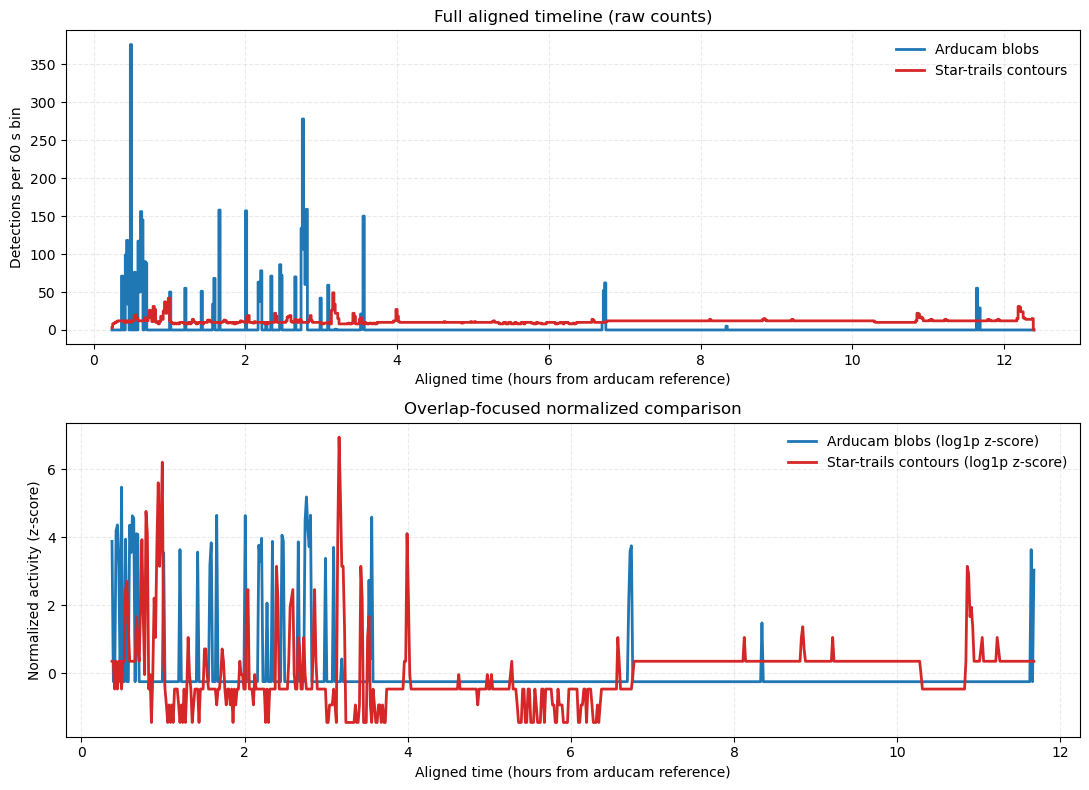


Caption-ready summary:
Using strict_lights_out_anchor_refined(+/-2 min) with 60 s bins, anchor lag=-332 s (-5.5 min), refined best lag=-480 s (-8.0 min); full-grid r=0.128, active-overlap r=0.162 (n_active_bins=93), and overlap normalized r=-0.020.


In [50]:
def build_binned_counts(df: pd.DataFrame, label: str, bin_size_s: float) -> pd.DataFrame:
    time_values = df['time_s'].dropna().to_numpy(dtype=float)
    if len(time_values) == 0:
        raise ValueError(f'No time values available for {label}')

    start = np.floor(time_values.min() / bin_size_s) * bin_size_s
    stop = np.ceil(time_values.max() / bin_size_s) * bin_size_s + bin_size_s
    bin_edges = np.arange(start, stop + bin_size_s, bin_size_s)
    counts, edges = np.histogram(time_values, bins=bin_edges)
    centers = edges[:-1] + bin_size_s / 2.0
    out = pd.DataFrame({
        'time_center_s': centers,
        'count': counts.astype(float),
        'view': label,
    })
    return out

def correlate_by_lag(reference: np.ndarray, target: np.ndarray, lag_steps: np.ndarray) -> pd.DataFrame:
    rows = []
    x = reference.astype(float)
    y = target.astype(float)
    for lag in lag_steps:
        shifted = np.interp(
            np.arange(len(x), dtype=float),
            np.arange(len(y), dtype=float) + lag,
            y,
            left=0.0,
            right=0.0,
        )
        if np.std(x) == 0 or np.std(shifted) == 0:
            corr_full = np.nan
        else:
            corr_full = float(np.corrcoef(x, shifted)[0, 1])

        active = (x > 0) & (shifted > 0)
        n_active = int(active.sum())
        if n_active >= 5 and np.std(x[active]) > 0 and np.std(shifted[active]) > 0:
            corr_active = float(np.corrcoef(x[active], shifted[active])[0, 1])
        else:
            corr_active = np.nan

        rows.append({
            'lag_steps': int(lag),
            'correlation_full': corr_full,
            'correlation_active': corr_active,
            'n_active_bins': n_active,
        })
    return pd.DataFrame(rows)

def zscore_safe(values: np.ndarray) -> np.ndarray:
    mu = np.mean(values)
    sd = np.std(values)
    if sd == 0:
        return np.zeros_like(values, dtype=float)
    return (values - mu) / sd

bin_size_s = 60.0
lag_step_s = bin_size_s

# Strict lights-out anchoring modes.
force_lights_out_anchor = True
lock_to_anchor_exact = False            # True -> evaluate only anchor lag
refine_minutes_around_anchor = 2        # tight local search around anchor

if force_lights_out_anchor and (gopro_lights_off_s is None or not np.isfinite(gopro_lights_off_s)):
    raise ValueError(
        'force_lights_out_anchor=True requires a valid gopro_lights_off_s. '
        'Set gopro_lights_off_s_manual in Cell 4 or enable auto-estimation there.'
    )

arducam_binned = build_binned_counts(arducam_df, 'arducam', bin_size_s)
contour_binned = build_binned_counts(contour_df, 'star_trails', bin_size_s)

# Put both series on a common bin grid for lag search.
common_start = min(arducam_binned['time_center_s'].min(), contour_binned['time_center_s'].min())
common_stop = max(arducam_binned['time_center_s'].max(), contour_binned['time_center_s'].max())
common_grid = np.arange(common_start, common_stop + bin_size_s, bin_size_s)

arducam_series = np.interp(common_grid, arducam_binned['time_center_s'], arducam_binned['count'], left=0.0, right=0.0)
contour_series = np.interp(common_grid, contour_binned['time_center_s'], contour_binned['count'], left=0.0, right=0.0)

# Light smoothing helps when the two detectors fire in short bursts.
arducam_series = pd.Series(arducam_series).rolling(window=3, center=True, min_periods=1).mean().to_numpy()
contour_series = pd.Series(contour_series).rolling(window=3, center=True, min_periods=1).mean().to_numpy()

anchor_lag_s = float(arducam_lights_off_s) - float(gopro_lights_off_s)
anchor_step = int(np.round(anchor_lag_s / lag_step_s))
if lock_to_anchor_exact:
    lag_steps = np.array([anchor_step], dtype=int)
    lag_metric = 'strict_lights_out_anchor_exact'
else:
    refine_steps = int((refine_minutes_around_anchor * 60) / lag_step_s)
    lag_steps = np.arange(anchor_step - refine_steps, anchor_step + refine_steps + 1)
    lag_metric = f'strict_lights_out_anchor_refined(+/-{refine_minutes_around_anchor} min)'

lag_scan = correlate_by_lag(arducam_series, contour_series, lag_steps)

# Select by full-grid correlation inside the anchor-centered refinement window.
best_idx = lag_scan['correlation_full'].idxmax()
best_lag_steps = int(lag_scan.loc[best_idx, 'lag_steps'])
best_lag_s = best_lag_steps * lag_step_s
best_corr_full = float(lag_scan.loc[best_idx, 'correlation_full']) if pd.notna(lag_scan.loc[best_idx, 'correlation_full']) else np.nan
best_corr_active = float(lag_scan.loc[best_idx, 'correlation_active']) if pd.notna(lag_scan.loc[best_idx, 'correlation_active']) else np.nan
best_n_active = int(lag_scan.loc[best_idx, 'n_active_bins'])

# Align star-trails contours to arducam time by shifting the contour axis.
contour_aligned = contour_binned.copy()
contour_aligned['time_aligned_s'] = contour_aligned['time_center_s'] - best_lag_s

arducam_aligned = arducam_binned.copy()
arducam_aligned['time_aligned_s'] = arducam_aligned['time_center_s']

aligned_union_start = min(arducam_aligned['time_aligned_s'].min(), contour_aligned['time_aligned_s'].min())
aligned_union_stop = max(arducam_aligned['time_aligned_s'].max(), contour_aligned['time_aligned_s'].max())
aligned_grid = np.arange(aligned_union_start, aligned_union_stop + bin_size_s, bin_size_s)

arducam_aligned_interp = np.interp(aligned_grid, arducam_aligned['time_aligned_s'], arducam_aligned['count'], left=0.0, right=0.0)
contour_aligned_interp = np.interp(aligned_grid, contour_aligned['time_aligned_s'], contour_aligned['count'], left=0.0, right=0.0)

aligned_counts = pd.DataFrame({
    'time_aligned_s': aligned_grid,
    'arducam_count': arducam_aligned_interp,
    'star_trails_count': contour_aligned_interp,
})

active_mask = aligned_counts['arducam_count'] > 0
if active_mask.any():
    overlap_start_s = float(aligned_counts.loc[active_mask, 'time_aligned_s'].min())
    overlap_stop_s = float(aligned_counts.loc[active_mask, 'time_aligned_s'].max())
else:
    overlap_start_s = float(aligned_counts['time_aligned_s'].min())
    overlap_stop_s = float(aligned_counts['time_aligned_s'].max())

overlap_df = aligned_counts[
    (aligned_counts['time_aligned_s'] >= overlap_start_s)
    & (aligned_counts['time_aligned_s'] <= overlap_stop_s)
] .copy()

arducam_log = np.log1p(overlap_df['arducam_count'].to_numpy(dtype=float))
star_log = np.log1p(overlap_df['star_trails_count'].to_numpy(dtype=float))
overlap_df['arducam_z'] = zscore_safe(arducam_log)
overlap_df['star_trails_z'] = zscore_safe(star_log)

if np.std(overlap_df['arducam_z']) == 0 or np.std(overlap_df['star_trails_z']) == 0:
    overlap_corr = np.nan
else:
    overlap_corr = float(np.corrcoef(overlap_df['arducam_z'], overlap_df['star_trails_z'])[0, 1])

print('Alignment summary')
print('=' * 72)
print(f'Bin size: {bin_size_s:.0f} s')
print(f'Lag selection metric: {lag_metric}')
print(f'force_lights_out_anchor = {force_lights_out_anchor}')
print(f'lock_to_anchor_exact = {lock_to_anchor_exact}')
print(f'arducam_lights_off_s = {arducam_lights_off_s}')
print(f'gopro_lights_off_s = {gopro_lights_off_s}')
print(f'Anchor lag from lights-out: {anchor_lag_s:.0f} s ({anchor_lag_s / 60:.1f} min)')
print(f'Best lag after local refinement: {best_lag_s:.0f} s ({best_lag_s / 60:.1f} min)')
print(f'Lag-correlation (full grid at best lag): {best_corr_full:.3f}')
print(f'Lag-correlation (active-overlap at best lag): {best_corr_active:.3f} (n_active_bins={best_n_active})')
print(
    f"Overlap window (Arducam active): {overlap_start_s / 3600:.2f} to {overlap_stop_s / 3600:.2f} h; "
    f"normalized correlation = {overlap_corr:.3f}"
 )

display(lag_scan.sort_values('correlation_full', ascending=False).head(10))
display(aligned_counts.head(10))

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=False)

# Panel 1: raw counts over full aligned timeline
axes[0].step(
    aligned_counts['time_aligned_s'] / 3600.0,
    aligned_counts['arducam_count'],
    where='mid',
    label='Arducam blobs',
    linewidth=2,
    color='#1f77b4',
)
axes[0].step(
    aligned_counts['time_aligned_s'] / 3600.0,
    aligned_counts['star_trails_count'],
    where='mid',
    label='Star-trails contours',
    linewidth=2,
    color='#d62728',
)
axes[0].set_xlabel('Aligned time (hours from arducam reference)')
axes[0].set_ylabel(f'Detections per {int(bin_size_s)} s bin')
axes[0].set_title('Full aligned timeline (raw counts)')
axes[0].legend(frameon=False)
axes[0].grid(True, linestyle='--', alpha=0.25)

# Panel 2: overlap-focused normalized comparison
axes[1].plot(
    overlap_df['time_aligned_s'] / 3600.0,
    overlap_df['arducam_z'],
    label='Arducam blobs (log1p z-score)',
    linewidth=2,
    color='#1f77b4',
)
axes[1].plot(
    overlap_df['time_aligned_s'] / 3600.0,
    overlap_df['star_trails_z'],
    label='Star-trails contours (log1p z-score)',
    linewidth=2,
    color='#d62728',
)
axes[1].set_xlabel('Aligned time (hours from arducam reference)')
axes[1].set_ylabel('Normalized activity (z-score)')
axes[1].set_title('Overlap-focused normalized comparison')
axes[1].legend(frameon=False)
axes[1].grid(True, linestyle='--', alpha=0.25)

plt.tight_layout()
plt.show()

corr_df = pd.DataFrame({
    'aligned_time_s': aligned_counts['time_aligned_s'],
    'arducam_count': aligned_counts['arducam_count'],
    'star_trails_count': aligned_counts['star_trails_count'],
})
print('\nCaption-ready summary:')
print(
    f"Using {lag_metric} with {int(bin_size_s)} s bins, anchor lag={anchor_lag_s:.0f} s "
    f"({anchor_lag_s / 60:.1f} min), refined best lag={best_lag_s:.0f} s "
    f"({best_lag_s / 60:.1f} min); full-grid r={best_corr_full:.3f}, "
    f"active-overlap r={best_corr_active:.3f} (n_active_bins={best_n_active}), and overlap normalized r={overlap_corr:.3f}."
 )

Sensitivity summary (near-start offsets)
Arducam offsets swept: [0.0, 30.0, 60.0, 90.0] s
GoPro offsets swept: [0.0, 30.0, 60.0, 90.0] s
Rows evaluated: 16
Best-lag range: -360 to -360 s (-6.0 to -6.0 min)
Correlation range (full-grid): 0.405 to 0.405


,arducam_offset_s,gopro_offset_s,anchor_lag_s,best_lag_s,best_corr_full,n_ard,n_gopro,lag_delta_from_anchor_s
0,0.0,0.0,-303.4,-360.0,0.405162,2993,8428,-56.6
1,0.0,30.0,-333.4,-360.0,0.405186,2993,8426,-26.6
2,0.0,60.0,-363.4,-360.0,0.405186,2993,8423,3.4
3,0.0,90.0,-393.4,-360.0,0.405243,2993,8420,33.4
4,30.0,0.0,-273.4,-360.0,0.405162,2993,8428,-86.6
5,30.0,30.0,-303.4,-360.0,0.405186,2993,8426,-56.6
6,30.0,60.0,-333.4,-360.0,0.405186,2993,8423,-26.6
7,30.0,90.0,-363.4,-360.0,0.405243,2993,8420,3.4
8,60.0,0.0,-243.4,-360.0,0.405162,2993,8428,-116.6
9,60.0,30.0,-273.4,-360.0,0.405186,2993,8426,-86.6


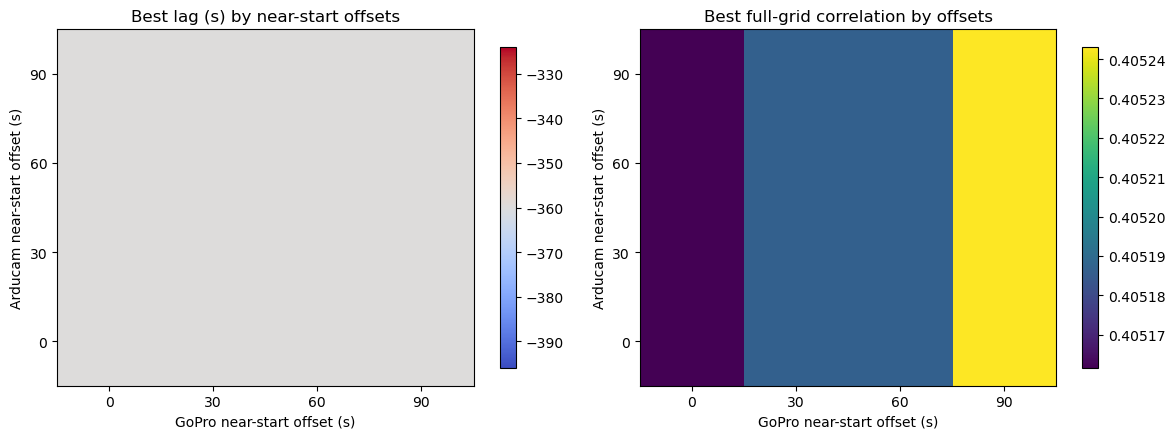

In [ ]:
# Sensitivity check: sweep near-start offsets using camera-meaningful increments.
# With GoPro timelapse at 0.03333 fps, one frame is ~30 s, so sub-second sweeps are not meaningful.
arducam_offset_grid_s = np.array([0.0, 30.0, 60.0, 90.0])
gopro_offset_grid_s = np.array([0.0, 30.0, 60.0, 90.0])
refine_minutes_for_sensitivity = 10

ard_raw = load_arducam_blobs(
    arducam_csv,
    arducam_fps=arducam_fps_known,
    arducam_part_duration_s=arducam_part_duration_fallback_s,
    use_detected_part_durations=arducam_use_detected_part_durations,
 )
gopro_raw = load_star_trails_contours(streak_csv)

records = []
for ard_offset_s in arducam_offset_grid_s:
    for gopro_offset_s in gopro_offset_grid_s:
        ard_anchor_s = float(ard_raw['time_s'].min()) + float(ard_offset_s)
        gopro_anchor_s = float(gopro_raw['time_s'].min()) + float(gopro_offset_s)

        # Match filtering logic from Cell 4.
        ard_keep_min_s = max(arducam_courtship_start_s, ard_anchor_s)
        ard_work = ard_raw[ard_raw['time_s'] >= ard_keep_min_s].copy()
        gopro_work = gopro_raw[gopro_raw['time_s'] >= gopro_anchor_s].copy()

        if exclude_static_lights and len(ard_work) > 0:
            mask = pd.Series(False, index=ard_work.index)
            for x_min, x_max, y_min, y_max in hotspot_windows:
                mask |= (
                    ard_work['x'].between(x_min, x_max)
                    & ard_work['y'].between(y_min, y_max)
                )
            ard_work = ard_work.loc[~mask].copy()

        if len(ard_work) == 0 or len(gopro_work) == 0:
            records.append({
                'arducam_offset_s': float(ard_offset_s),
                'gopro_offset_s': float(gopro_offset_s),
                'anchor_lag_s': np.nan,
                'best_lag_s': np.nan,
                'best_corr_full': np.nan,
                'n_ard': int(len(ard_work)),
                'n_gopro': int(len(gopro_work)),
            })
            continue

        ard_bin = build_binned_counts(ard_work, 'arducam', bin_size_s)
        gopro_bin = build_binned_counts(gopro_work, 'star_trails', bin_size_s)

        common_start = min(ard_bin['time_center_s'].min(), gopro_bin['time_center_s'].min())
        common_stop = max(ard_bin['time_center_s'].max(), gopro_bin['time_center_s'].max())
        common_grid = np.arange(common_start, common_stop + bin_size_s, bin_size_s)

        ard_series = np.interp(common_grid, ard_bin['time_center_s'], ard_bin['count'], left=0.0, right=0.0)
        gopro_series = np.interp(common_grid, gopro_bin['time_center_s'], gopro_bin['count'], left=0.0, right=0.0)
        ard_series = pd.Series(ard_series).rolling(window=3, center=True, min_periods=1).mean().to_numpy()
        gopro_series = pd.Series(gopro_series).rolling(window=3, center=True, min_periods=1).mean().to_numpy()

        anchor_lag_s = float(ard_anchor_s) - float(gopro_anchor_s)
        anchor_step = int(np.round(anchor_lag_s / lag_step_s))
        refine_steps = int((refine_minutes_for_sensitivity * 60) / lag_step_s)
        lag_steps_local = np.arange(anchor_step - refine_steps, anchor_step + refine_steps + 1)

        scan = correlate_by_lag(ard_series, gopro_series, lag_steps_local)
        best_idx = scan['correlation_full'].idxmax()
        best_lag_s_local = float(scan.loc[best_idx, 'lag_steps']) * lag_step_s
        best_corr_local = float(scan.loc[best_idx, 'correlation_full'])

        records.append({
            'arducam_offset_s': float(ard_offset_s),
            'gopro_offset_s': float(gopro_offset_s),
            'anchor_lag_s': anchor_lag_s,
            'best_lag_s': best_lag_s_local,
            'best_corr_full': best_corr_local,
            'n_ard': int(len(ard_work)),
            'n_gopro': int(len(gopro_work)),
        })

sens_df = pd.DataFrame(records).sort_values(['arducam_offset_s', 'gopro_offset_s']).reset_index(drop=True)
sens_df['lag_delta_from_anchor_s'] = sens_df['best_lag_s'] - sens_df['anchor_lag_s']

print('Sensitivity summary (near-start offsets)')
print('=' * 72)
print(f'Arducam offsets swept: {arducam_offset_grid_s.tolist()} s')
print(f'GoPro offsets swept: {gopro_offset_grid_s.tolist()} s')
print(f'Rows evaluated: {len(sens_df)}')
print(
    f"Best-lag range: {sens_df['best_lag_s'].min():.0f} to {sens_df['best_lag_s'].max():.0f} s "
    f"({sens_df['best_lag_s'].min()/60:.1f} to {sens_df['best_lag_s'].max()/60:.1f} min)"
 )
print(
    f"Correlation range (full-grid): {sens_df['best_corr_full'].min():.3f} to "
    f"{sens_df['best_corr_full'].max():.3f}"
 )

display(sens_df.head(12))

lag_pivot = sens_df.pivot(index='arducam_offset_s', columns='gopro_offset_s', values='best_lag_s')
corr_pivot = sens_df.pivot(index='arducam_offset_s', columns='gopro_offset_s', values='best_corr_full')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

im0 = axes[0].imshow(lag_pivot.values, aspect='auto', origin='lower', cmap='coolwarm')
axes[0].set_title('Best lag (s) by near-start offsets')
axes[0].set_xlabel('GoPro near-start offset (s)')
axes[0].set_ylabel('Arducam near-start offset (s)')
axes[0].set_xticks(np.arange(len(lag_pivot.columns)))
axes[0].set_xticklabels([f'{v:.0f}' for v in lag_pivot.columns])
axes[0].set_yticks(np.arange(len(lag_pivot.index)))
axes[0].set_yticklabels([f'{v:.0f}' for v in lag_pivot.index])
fig.colorbar(im0, ax=axes[0], shrink=0.9)

im1 = axes[1].imshow(corr_pivot.values, aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title('Best full-grid correlation by offsets')
axes[1].set_xlabel('GoPro near-start offset (s)')
axes[1].set_ylabel('Arducam near-start offset (s)')
axes[1].set_xticks(np.arange(len(corr_pivot.columns)))
axes[1].set_xticklabels([f'{v:.0f}' for v in corr_pivot.columns])
axes[1].set_yticks(np.arange(len(corr_pivot.index)))
axes[1].set_yticklabels([f'{v:.0f}' for v in corr_pivot.index])
fig.colorbar(im1, ax=axes[1], shrink=0.9)

plt.tight_layout()
plt.show()

Absolute count comparison (GoPro cadence)
Using aligned lag: -480 s (-8.0 min)
GoPro cadence / exposure used: 30.00 s per frame
Frames compared: 1457


,simulation,pearson_r,mae,bias
0,B_presence_seconds,-0.032864,5.673988,-5.509266
1,C_cap1_per_sec,-0.032864,5.673988,-5.509266
2,D_cap2_per_sec,-0.034284,5.893617,-5.258065
3,A_blob_window,-0.033275,7.914207,-3.231984


Best simulation by MAE: B_presence_seconds


,t_aligned_s,gopro_count,arducam_sim_blob_count,arducam_sim_presence_seconds,arducam_sim_cap1_count,arducam_sim_cap2_count,diff_blob,diff_presence,diff_cap1,diff_cap2
0,870.0,3,0.0,0.0,0.0,0.0,-3.0,-3.0,-3.0,-3.0
1,900.0,4,0.0,0.0,0.0,0.0,-4.0,-4.0,-4.0,-4.0
2,930.0,4,0.0,0.0,0.0,0.0,-4.0,-4.0,-4.0,-4.0
3,960.0,4,0.0,0.0,0.0,0.0,-4.0,-4.0,-4.0,-4.0
4,990.0,5,0.0,0.0,0.0,0.0,-5.0,-5.0,-5.0,-5.0
5,1020.0,5,0.0,0.0,0.0,0.0,-5.0,-5.0,-5.0,-5.0
6,1050.0,5,0.0,0.0,0.0,0.0,-5.0,-5.0,-5.0,-5.0
7,1080.0,5,0.0,0.0,0.0,0.0,-5.0,-5.0,-5.0,-5.0
8,1110.0,6,0.0,0.0,0.0,0.0,-6.0,-6.0,-6.0,-6.0
9,1140.0,6,0.0,0.0,0.0,0.0,-6.0,-6.0,-6.0,-6.0


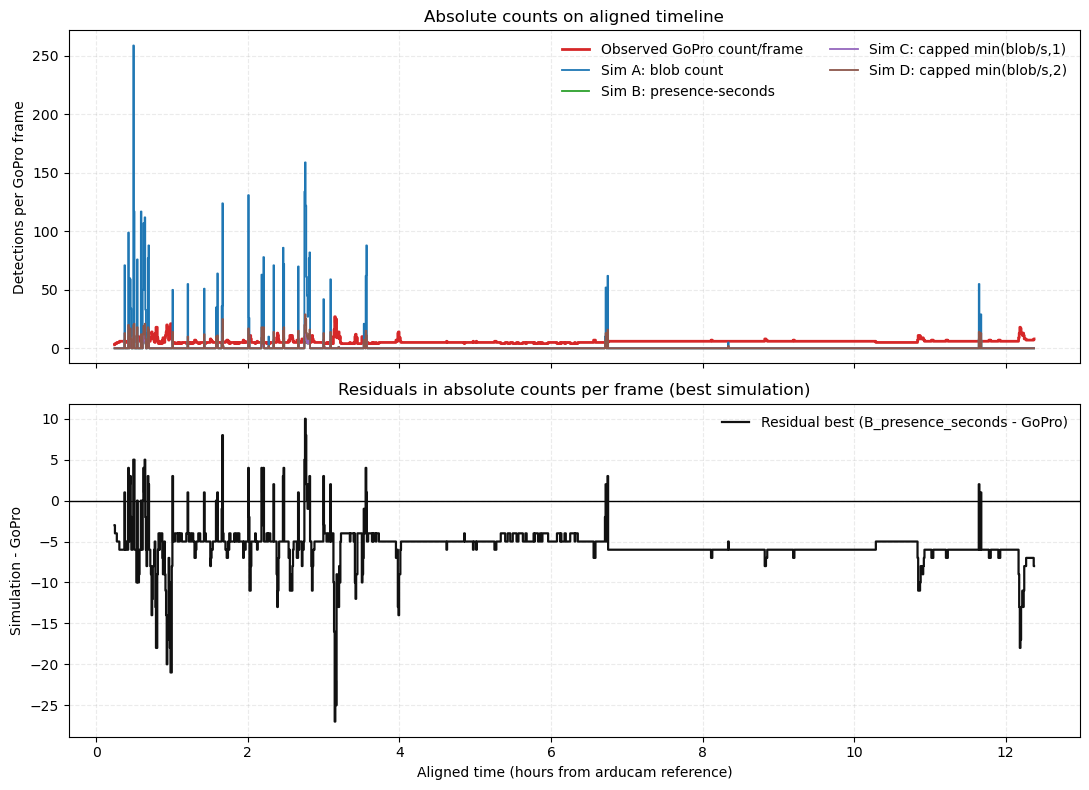

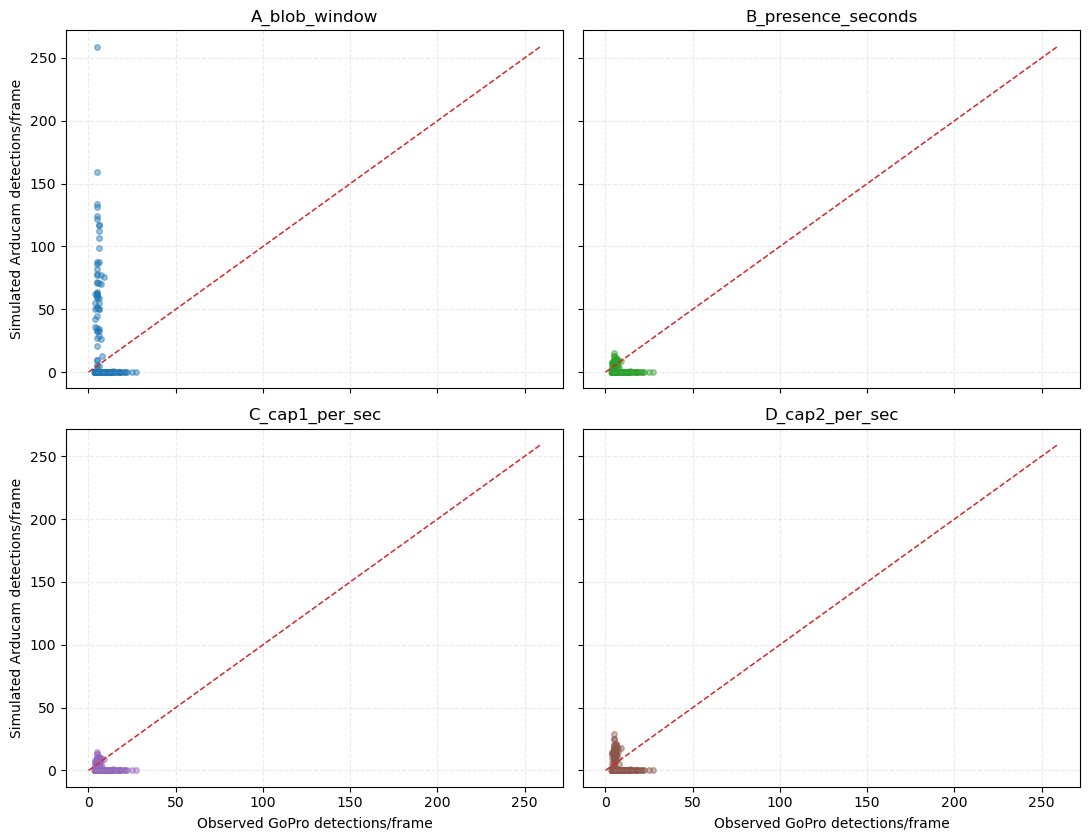

In [51]:
# Absolute-count comparison at GoPro frame cadence (30 s windows).
if 'best_lag_s' not in globals():
    raise ValueError('Run Cell 6 first so best_lag_s is available.')

# Align GoPro frame timestamps into Arducam time reference.
gopro_aligned_time_s = contour_df['time_s'].to_numpy(dtype=float) - float(best_lag_s)
gopro_frame_counts = (
    pd.DataFrame({'t_aligned_s': gopro_aligned_time_s})
    .groupby('t_aligned_s', as_index=False)
    .size()
    .rename(columns={'size': 'gopro_count'})
    .sort_values('t_aligned_s')
    .reset_index(drop=True)
 )

# Use metadata-based cadence for exposure simulation.
exposure_s = float(gopro_sampling_interval_s)
frame_times = gopro_frame_counts['t_aligned_s'].to_numpy(dtype=float)

# Base simulation: raw Arducam blob counts in each [t-exposure_s, t] window.
ard_times = np.sort(arducam_df['time_s'].to_numpy(dtype=float))
left_idx = np.searchsorted(ard_times, frame_times - exposure_s, side='left')
right_idx = np.searchsorted(ard_times, frame_times, side='right')
ard_sim_blob_count = (right_idx - left_idx).astype(float)

# Event-like simulation B: per-second presence integrated over exposure window.
ard_sec_counts = pd.Series(np.floor(ard_times).astype(int)).value_counts().sort_index()
ard_seconds = ard_sec_counts.index.to_numpy(dtype=int)

sec_left = np.searchsorted(ard_seconds, np.floor(frame_times - exposure_s).astype(int), side='left')
sec_right = np.searchsorted(ard_seconds, np.floor(frame_times).astype(int), side='right')
ard_sim_presence_seconds = (sec_right - sec_left).astype(float)

# Event-like simulation C/D: capped per-second blob rate before 30 s integration.
capped_1_per_sec = np.minimum(ard_sec_counts.to_numpy(dtype=float), 1.0)
capped_2_per_sec = np.minimum(ard_sec_counts.to_numpy(dtype=float), 2.0)
prefix_c1 = np.concatenate([[0.0], np.cumsum(capped_1_per_sec)])
prefix_c2 = np.concatenate([[0.0], np.cumsum(capped_2_per_sec)])
ard_sim_cap1_count = prefix_c1[sec_right] - prefix_c1[sec_left]
ard_sim_cap2_count = prefix_c2[sec_right] - prefix_c2[sec_left]

absolute_compare_df = gopro_frame_counts.copy()
absolute_compare_df['arducam_sim_blob_count'] = ard_sim_blob_count
absolute_compare_df['arducam_sim_presence_seconds'] = ard_sim_presence_seconds
absolute_compare_df['arducam_sim_cap1_count'] = ard_sim_cap1_count
absolute_compare_df['arducam_sim_cap2_count'] = ard_sim_cap2_count

absolute_compare_df['diff_blob'] = absolute_compare_df['arducam_sim_blob_count'] - absolute_compare_df['gopro_count']
absolute_compare_df['diff_presence'] = absolute_compare_df['arducam_sim_presence_seconds'] - absolute_compare_df['gopro_count']
absolute_compare_df['diff_cap1'] = absolute_compare_df['arducam_sim_cap1_count'] - absolute_compare_df['gopro_count']
absolute_compare_df['diff_cap2'] = absolute_compare_df['arducam_sim_cap2_count'] - absolute_compare_df['gopro_count']

def summarize_abs_metrics(obs: np.ndarray, sim: np.ndarray) -> tuple[float, float, float]:
    if len(obs) >= 2 and np.std(obs) > 0 and np.std(sim) > 0:
        corr = float(np.corrcoef(obs, sim)[0, 1])
    else:
        corr = np.nan
    mae = float(np.mean(np.abs(sim - obs)))
    bias = float(np.mean(sim - obs))
    return corr, mae, bias

obs = absolute_compare_df['gopro_count'].to_numpy(dtype=float)
sim_blob = absolute_compare_df['arducam_sim_blob_count'].to_numpy(dtype=float)
sim_presence = absolute_compare_df['arducam_sim_presence_seconds'].to_numpy(dtype=float)
sim_cap1 = absolute_compare_df['arducam_sim_cap1_count'].to_numpy(dtype=float)
sim_cap2 = absolute_compare_df['arducam_sim_cap2_count'].to_numpy(dtype=float)

corr_blob, mae_blob, bias_blob = summarize_abs_metrics(obs, sim_blob)
corr_presence, mae_presence, bias_presence = summarize_abs_metrics(obs, sim_presence)
corr_cap1, mae_cap1, bias_cap1 = summarize_abs_metrics(obs, sim_cap1)
corr_cap2, mae_cap2, bias_cap2 = summarize_abs_metrics(obs, sim_cap2)

summary_rows = [
    ('A_blob_window', corr_blob, mae_blob, bias_blob),
    ('B_presence_seconds', corr_presence, mae_presence, bias_presence),
    ('C_cap1_per_sec', corr_cap1, mae_cap1, bias_cap1),
    ('D_cap2_per_sec', corr_cap2, mae_cap2, bias_cap2),
]
abs_summary_df = pd.DataFrame(summary_rows, columns=['simulation', 'pearson_r', 'mae', 'bias'])
abs_summary_df = abs_summary_df.sort_values('mae').reset_index(drop=True)

best_sim_name = abs_summary_df.loc[0, 'simulation']
if best_sim_name == 'A_blob_window':
    best_sim = sim_blob
    best_diff = absolute_compare_df['diff_blob'].to_numpy(dtype=float)
elif best_sim_name == 'B_presence_seconds':
    best_sim = sim_presence
    best_diff = absolute_compare_df['diff_presence'].to_numpy(dtype=float)
elif best_sim_name == 'C_cap1_per_sec':
    best_sim = sim_cap1
    best_diff = absolute_compare_df['diff_cap1'].to_numpy(dtype=float)
else:
    best_sim = sim_cap2
    best_diff = absolute_compare_df['diff_cap2'].to_numpy(dtype=float)

print('Absolute count comparison (GoPro cadence)')
print('=' * 72)
print(f'Using aligned lag: {best_lag_s:.0f} s ({best_lag_s/60:.1f} min)')
print(f'GoPro cadence / exposure used: {exposure_s:.2f} s per frame')
print(f'Frames compared: {len(absolute_compare_df)}')
display(abs_summary_df)
print(f'Best simulation by MAE: {best_sim_name}')

display(absolute_compare_df.head(15))

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Panel 1: time-series absolute counts per frame.
axes[0].step(
    absolute_compare_df['t_aligned_s'] / 3600.0,
    absolute_compare_df['gopro_count'],
    where='mid',
    label='Observed GoPro count/frame',
    linewidth=2,
    color='#d62728',
)
axes[0].step(
    absolute_compare_df['t_aligned_s'] / 3600.0,
    absolute_compare_df['arducam_sim_blob_count'],
    where='mid',
    label='Sim A: blob count',
    linewidth=1.3,
    color='#1f77b4',
)
axes[0].step(
    absolute_compare_df['t_aligned_s'] / 3600.0,
    absolute_compare_df['arducam_sim_presence_seconds'],
    where='mid',
    label='Sim B: presence-seconds',
    linewidth=1.3,
    color='#2ca02c',
)
axes[0].step(
    absolute_compare_df['t_aligned_s'] / 3600.0,
    absolute_compare_df['arducam_sim_cap1_count'],
    where='mid',
    label='Sim C: capped min(blob/s,1)',
    linewidth=1.3,
    color='#9467bd',
)
axes[0].step(
    absolute_compare_df['t_aligned_s'] / 3600.0,
    absolute_compare_df['arducam_sim_cap2_count'],
    where='mid',
    label='Sim D: capped min(blob/s,2)',
    linewidth=1.3,
    color='#8c564b',
)
axes[0].set_ylabel('Detections per GoPro frame')
axes[0].set_title('Absolute counts on aligned timeline')
axes[0].legend(frameon=False, loc='upper right', ncol=2)
axes[0].grid(True, linestyle='--', alpha=0.25)

# Panel 2: residuals for best simulation.
axes[1].axhline(0.0, color='black', linewidth=1)
axes[1].step(
    absolute_compare_df['t_aligned_s'] / 3600.0,
    best_diff,
    where='mid',
    linewidth=1.6,
    color='#111111',
    label=f'Residual best ({best_sim_name} - GoPro)',
 )
axes[1].set_xlabel('Aligned time (hours from arducam reference)')
axes[1].set_ylabel('Simulation - GoPro')
axes[1].set_title('Residuals in absolute counts per frame (best simulation)')
axes[1].legend(frameon=False, loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.25)

plt.tight_layout()
plt.show()

# Scatter diagnostics for all simulations.
fig, scatter_axes = plt.subplots(2, 2, figsize=(11, 8.5), sharex=True, sharey=True)
sim_items = [
    ('A_blob_window', sim_blob, '#1f77b4'),
    ('B_presence_seconds', sim_presence, '#2ca02c'),
    ('C_cap1_per_sec', sim_cap1, '#9467bd'),
    ('D_cap2_per_sec', sim_cap2, '#8c564b'),
]

max_xy = float(max(obs.max(), sim_blob.max(), sim_presence.max(), sim_cap1.max(), sim_cap2.max()))

for ax, (name, sim_vals, color) in zip(scatter_axes.flatten(), sim_items):
    ax.scatter(obs, sim_vals, alpha=0.45, s=16, color=color)
    ax.plot([0, max_xy], [0, max_xy], linestyle='--', color='#d62728', linewidth=1.1)
    ax.set_title(name)
    ax.grid(True, linestyle='--', alpha=0.25)

scatter_axes[1, 0].set_xlabel('Observed GoPro detections/frame')
scatter_axes[1, 1].set_xlabel('Observed GoPro detections/frame')
scatter_axes[0, 0].set_ylabel('Simulated Arducam detections/frame')
scatter_axes[1, 0].set_ylabel('Simulated Arducam detections/frame')
plt.tight_layout()
plt.show()

## Absolute-count comparison and GoPro exposure simulation

This section avoids normalization and compares absolute detections directly.

We simulate GoPro long-exposure sampling from Arducam by counting Arducam detections in each 30 s exposure window ending at each aligned GoPro frame timestamp, then compare simulated vs observed GoPro detections per frame.

## Transfer model in absolute units

This fits a robust linear transfer from simulated Arducam counts to observed GoPro counts.

The robust fit uses Huber-style iterative reweighting so early spike windows are downweighted rather than removed.

Absolute transfer model summary
Lower MAE / RMSE is better; higher correlation is better.


,model,intercept,slope,corr,mae,rmse,bias
0,A_blob_ols,5.767977,0.006357,0.055979,0.972424,1.902313,-4.037950e-15
1,B_presence_ols,5.764425,0.081590,0.063090,0.974096,1.901505,-2.223799e-15
2,A_blob_huber,5.534564,0.004648,0.055979,0.977996,1.917225,-2.369304e-01
3,B_presence_huber,5.533612,0.052980,0.063090,0.978023,1.916637,-2.366454e-01


Best model by MAE: A_blob_ols


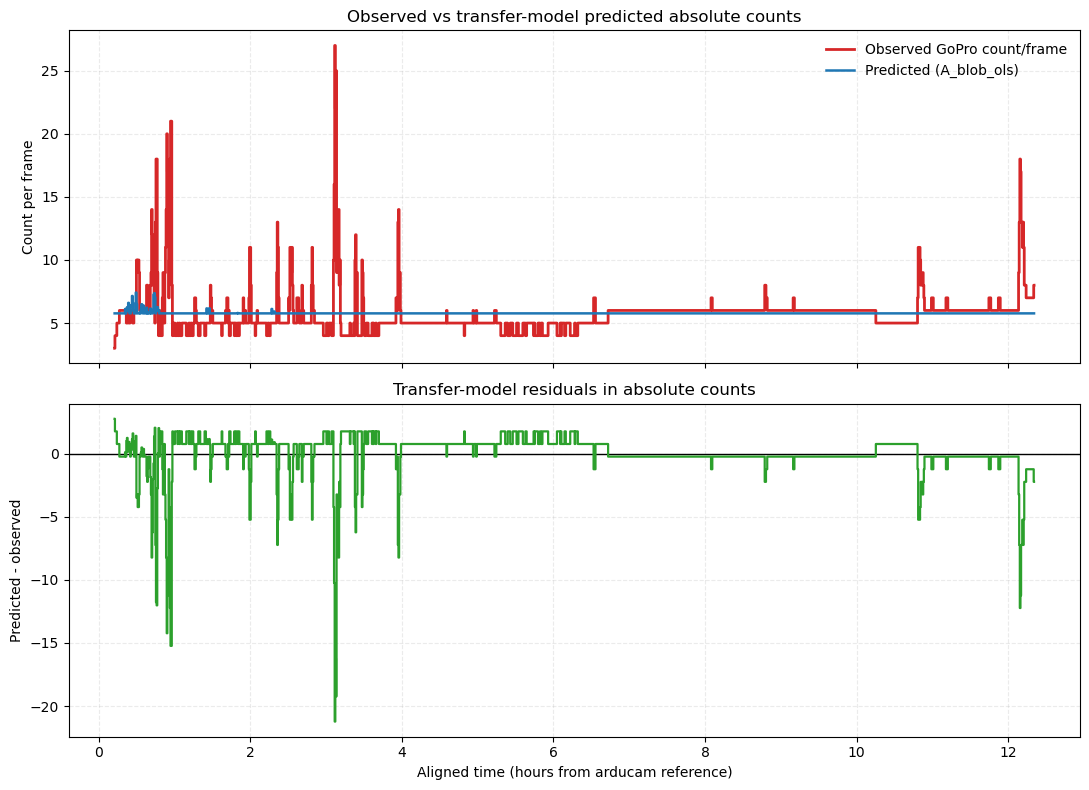

In [44]:
if 'absolute_compare_df' not in globals():
    raise ValueError('Run the absolute-count simulation cell first.')

def fit_linear_ols(x: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    X = np.column_stack([np.ones(len(x)), x])
    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta
    return beta, y_hat

def fit_linear_huber(
    x: np.ndarray,
    y: np.ndarray,
    delta: float = 2.0,
    max_iter: int = 50,
    tol: float = 1e-6,
 ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    X = np.column_stack([np.ones(len(x)), x])
    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)

    for _ in range(max_iter):
        y_hat = X @ beta
        resid = y - y_hat
        abs_resid = np.abs(resid)
        weights = np.where(abs_resid <= delta, 1.0, delta / np.maximum(abs_resid, 1e-12))

        Xw = X * np.sqrt(weights)[:, None]
        yw = y * np.sqrt(weights)
        beta_new, _, _, _ = np.linalg.lstsq(Xw, yw, rcond=None)

        if np.max(np.abs(beta_new - beta)) < tol:
            beta = beta_new
            break
        beta = beta_new

    y_hat = X @ beta
    resid = y - y_hat
    abs_resid = np.abs(resid)
    weights = np.where(abs_resid <= delta, 1.0, delta / np.maximum(abs_resid, 1e-12))
    return beta, y_hat, weights

def metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    if len(y_true) >= 2 and np.std(y_true) > 0 and np.std(y_pred) > 0:
        corr = float(np.corrcoef(y_true, y_pred)[0, 1])
    else:
        corr = np.nan
    mae = float(np.mean(np.abs(y_pred - y_true)))
    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    bias = float(np.mean(y_pred - y_true))
    return {'corr': corr, 'mae': mae, 'rmse': rmse, 'bias': bias}

y = absolute_compare_df['gopro_count'].to_numpy(dtype=float)
x_blob = absolute_compare_df['arducam_sim_blob_count'].to_numpy(dtype=float)
x_presence = absolute_compare_df['arducam_sim_presence_seconds'].to_numpy(dtype=float)

# OLS and robust fits for both simulation variants.
beta_blob_ols, yhat_blob_ols = fit_linear_ols(x_blob, y)
beta_presence_ols, yhat_presence_ols = fit_linear_ols(x_presence, y)

beta_blob_h, yhat_blob_h, w_blob = fit_linear_huber(x_blob, y, delta=2.0)
beta_presence_h, yhat_presence_h, w_presence = fit_linear_huber(x_presence, y, delta=2.0)

# Clamp predictions to non-negative counts for reporting/plots.
yhat_blob_ols = np.clip(yhat_blob_ols, 0.0, None)
yhat_presence_ols = np.clip(yhat_presence_ols, 0.0, None)
yhat_blob_h = np.clip(yhat_blob_h, 0.0, None)
yhat_presence_h = np.clip(yhat_presence_h, 0.0, None)

m_blob_ols = metrics(y, yhat_blob_ols)
m_presence_ols = metrics(y, yhat_presence_ols)
m_blob_h = metrics(y, yhat_blob_h)
m_presence_h = metrics(y, yhat_presence_h)

model_rows = [
    {
        'model': 'A_blob_ols',
        'intercept': float(beta_blob_ols[0]),
        'slope': float(beta_blob_ols[1]),
        **m_blob_ols,
    },
    {
        'model': 'B_presence_ols',
        'intercept': float(beta_presence_ols[0]),
        'slope': float(beta_presence_ols[1]),
        **m_presence_ols,
    },
    {
        'model': 'A_blob_huber',
        'intercept': float(beta_blob_h[0]),
        'slope': float(beta_blob_h[1]),
        **m_blob_h,
    },
    {
        'model': 'B_presence_huber',
        'intercept': float(beta_presence_h[0]),
        'slope': float(beta_presence_h[1]),
        **m_presence_h,
    },
]
transfer_df = pd.DataFrame(model_rows).sort_values('mae').reset_index(drop=True)
best_model_name = transfer_df.loc[0, 'model']

if best_model_name == 'A_blob_ols':
    best_pred = yhat_blob_ols
elif best_model_name == 'B_presence_ols':
    best_pred = yhat_presence_ols
elif best_model_name == 'A_blob_huber':
    best_pred = yhat_blob_h
else:
    best_pred = yhat_presence_h

print('Absolute transfer model summary')
print('=' * 72)
print('Lower MAE / RMSE is better; higher correlation is better.')
display(transfer_df)
print(f'Best model by MAE: {best_model_name}')

transfer_pred_df = absolute_compare_df[['t_aligned_s', 'gopro_count']].copy()
transfer_pred_df['pred_count'] = best_pred
transfer_pred_df['residual'] = transfer_pred_df['pred_count'] - transfer_pred_df['gopro_count']

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
axes[0].step(
    transfer_pred_df['t_aligned_s'] / 3600.0,
    transfer_pred_df['gopro_count'],
    where='mid',
    label='Observed GoPro count/frame',
    color='#d62728',
    linewidth=2,
 )
axes[0].step(
    transfer_pred_df['t_aligned_s'] / 3600.0,
    transfer_pred_df['pred_count'],
    where='mid',
    label=f'Predicted ({best_model_name})',
    color='#1f77b4',
    linewidth=1.8,
 )
axes[0].set_ylabel('Count per frame')
axes[0].set_title('Observed vs transfer-model predicted absolute counts')
axes[0].legend(frameon=False)
axes[0].grid(True, linestyle='--', alpha=0.25)

axes[1].axhline(0.0, color='black', linewidth=1.0)
axes[1].step(
    transfer_pred_df['t_aligned_s'] / 3600.0,
    transfer_pred_df['residual'],
    where='mid',
    color='#2ca02c',
    linewidth=1.6,
 )
axes[1].set_xlabel('Aligned time (hours from arducam reference)')
axes[1].set_ylabel('Predicted - observed')
axes[1].set_title('Transfer-model residuals in absolute counts')
axes[1].grid(True, linestyle='--', alpha=0.25)
plt.tight_layout()
plt.show()

# Plot Huber weights for the robust winner to show downweighting behavior.
if 'huber' in best_model_name:
    if best_model_name == 'A_blob_huber':
        best_weights = w_blob
    else:
        best_weights = w_presence

    plt.figure(figsize=(11, 2.8))
    plt.plot(transfer_pred_df['t_aligned_s'] / 3600.0, best_weights, color='#444444', linewidth=1.4)
    plt.ylim(0, 1.05)
    plt.xlabel('Aligned time (hours from arducam reference)')
    plt.ylabel('Huber weight')
    plt.title('Robust-fit weights (lower means downweighted outlier windows)')
    plt.grid(True, linestyle='--', alpha=0.25)
    plt.tight_layout()
    plt.show()

Calibration on absolute counts (chronological split)
Base simulation entering calibration: B_presence_seconds (arducam_sim_presence_seconds)
Train/Test split: 1019 / 438 frames (70%/30%)


,model,train_mae,test_mae,train_rmse,test_rmse,train_bias,test_bias,train_r,test_r
0,sqrt_link,1.081983,0.721650,2.090350,1.408424,2.005418e-14,-0.532243,2.074890e-02,8.295955e-03
1,affine_linear,1.082171,0.722175,2.090359,1.408716,1.773916e-14,-0.533017,2.052304e-02,8.282126e-03
2,piecewise_quantile,1.082897,0.727887,2.090800,1.412012,-8.367530e-17,-0.541564,8.004143e-16,-1.231586e-15
3,raw_identity,5.473994,6.139269,5.910022,6.284176,-5.244357e+00,-6.125571,-2.052304e-02,-8.282126e-03


Best calibration model by test MAE: sqrt_link


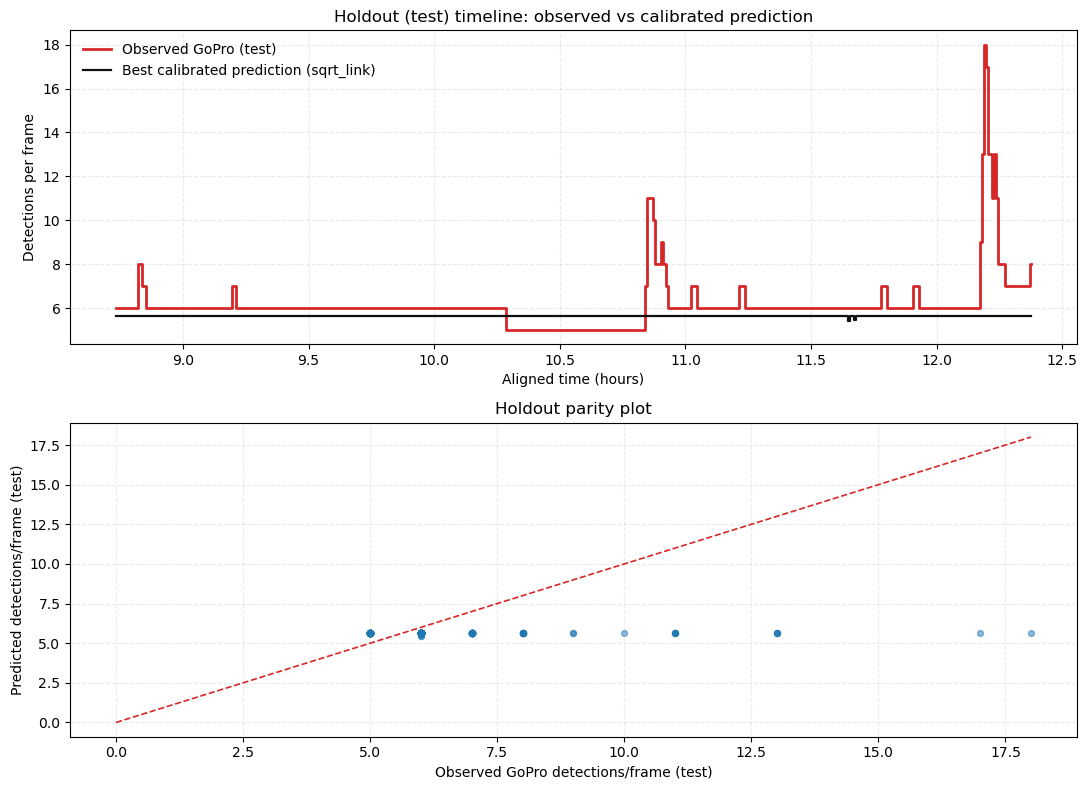

In [52]:
# Train/test calibration on absolute counts (chronological split).
if 'absolute_compare_df' not in globals() or 'abs_summary_df' not in globals():
    raise ValueError('Run the absolute comparison cell first to create absolute_compare_df and abs_summary_df.')

base_map = {
    'A_blob_window': 'arducam_sim_blob_count',
    'B_presence_seconds': 'arducam_sim_presence_seconds',
    'C_cap1_per_sec': 'arducam_sim_cap1_count',
    'D_cap2_per_sec': 'arducam_sim_cap2_count',
}
base_sim_name = str(abs_summary_df.loc[0, 'simulation'])
base_col = base_map[base_sim_name]

calib_df = absolute_compare_df[['t_aligned_s', 'gopro_count', base_col]].copy()
calib_df = calib_df.rename(columns={base_col: 'sim_base'})
calib_df = calib_df.sort_values('t_aligned_s').reset_index(drop=True)

n_total = len(calib_df)
if n_total < 50:
    raise ValueError(f'Not enough frames for train/test split: {n_total}')

split_frac = 0.70
split_idx = int(np.floor(split_frac * n_total))
split_idx = max(20, min(split_idx, n_total - 20))

train = calib_df.iloc[:split_idx].copy()
test = calib_df.iloc[split_idx:].copy()

x_train = train['sim_base'].to_numpy(dtype=float)
y_train = train['gopro_count'].to_numpy(dtype=float)
x_test = test['sim_base'].to_numpy(dtype=float)
y_test = test['gopro_count'].to_numpy(dtype=float)

def fit_linear_affine(x: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    X = np.column_stack([np.ones_like(x), x])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return float(beta[0]), float(beta[1])

def pred_linear_affine(x: np.ndarray, a: float, b: float) -> np.ndarray:
    return np.maximum(0.0, a + b * x)

def fit_sqrt_link(x: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    z = np.sqrt(np.maximum(x, 0.0))
    X = np.column_stack([np.ones_like(z), z])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return float(beta[0]), float(beta[1])

def pred_sqrt_link(x: np.ndarray, a: float, b: float) -> np.ndarray:
    z = np.sqrt(np.maximum(x, 0.0))
    return np.maximum(0.0, a + b * z)

def fit_piecewise_quantile_map(x: np.ndarray, y: np.ndarray, n_bins: int = 8):
    q = np.linspace(0.0, 1.0, n_bins + 1)
    edges = np.quantile(x, q)
    edges = np.unique(edges)
    if len(edges) < 2:
        return None, None

    bin_idx = np.digitize(x, edges[1:-1], right=True)
    means = np.zeros(len(edges) - 1, dtype=float)
    global_mean = float(np.mean(y))
    for i in range(len(means)):
        mask = bin_idx == i
        means[i] = float(np.mean(y[mask])) if np.any(mask) else global_mean
    return edges, means

def pred_piecewise_quantile_map(x: np.ndarray, edges: np.ndarray, means: np.ndarray) -> np.ndarray:
    idx = np.digitize(x, edges[1:-1], right=True)
    idx = np.clip(idx, 0, len(means) - 1)
    return np.maximum(0.0, means[idx])

def metrics(obs: np.ndarray, pred: np.ndarray) -> dict:
    err = pred - obs
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err ** 2)))
    bias = float(np.mean(err))
    if len(obs) >= 2 and np.std(obs) > 0 and np.std(pred) > 0:
        r = float(np.corrcoef(obs, pred)[0, 1])
    else:
        r = np.nan
    return {'mae': mae, 'rmse': rmse, 'bias': bias, 'pearson_r': r}

model_preds = {}

# Baseline: no calibration.
model_preds['raw_identity'] = {
    'train': np.maximum(0.0, x_train),
    'test': np.maximum(0.0, x_test),
}

# Affine map.
a_lin, b_lin = fit_linear_affine(x_train, y_train)
model_preds['affine_linear'] = {
    'train': pred_linear_affine(x_train, a_lin, b_lin),
    'test': pred_linear_affine(x_test, a_lin, b_lin),
    'params': {'a': a_lin, 'b': b_lin},
}

# Sqrt-link map (Poisson-like variance stabilization).
a_sqrt, b_sqrt = fit_sqrt_link(x_train, y_train)
model_preds['sqrt_link'] = {
    'train': pred_sqrt_link(x_train, a_sqrt, b_sqrt),
    'test': pred_sqrt_link(x_test, a_sqrt, b_sqrt),
    'params': {'a': a_sqrt, 'b': b_sqrt},
}

# Piecewise quantile map.
edges_pw, means_pw = fit_piecewise_quantile_map(x_train, y_train, n_bins=8)
if edges_pw is not None:
    model_preds['piecewise_quantile'] = {
        'train': pred_piecewise_quantile_map(x_train, edges_pw, means_pw),
        'test': pred_piecewise_quantile_map(x_test, edges_pw, means_pw),
        'params': {'n_bins': int(len(means_pw)), 'edges': edges_pw},
    }

rows = []
for model_name, pred_pack in model_preds.items():
    mtr_train = metrics(y_train, pred_pack['train'])
    mtr_test = metrics(y_test, pred_pack['test'])
    rows.append({
        'model': model_name,
        'train_mae': mtr_train['mae'],
        'test_mae': mtr_test['mae'],
        'train_rmse': mtr_train['rmse'],
        'test_rmse': mtr_test['rmse'],
        'train_bias': mtr_train['bias'],
        'test_bias': mtr_test['bias'],
        'train_r': mtr_train['pearson_r'],
        'test_r': mtr_test['pearson_r'],
    })

calib_summary_df = pd.DataFrame(rows).sort_values('test_mae').reset_index(drop=True)
best_calib_model = str(calib_summary_df.loc[0, 'model'])

full_x = calib_df['sim_base'].to_numpy(dtype=float)
if best_calib_model == 'raw_identity':
    full_pred = np.maximum(0.0, full_x)
elif best_calib_model == 'affine_linear':
    full_pred = pred_linear_affine(full_x, a_lin, b_lin)
elif best_calib_model == 'sqrt_link':
    full_pred = pred_sqrt_link(full_x, a_sqrt, b_sqrt)
else:
    full_pred = pred_piecewise_quantile_map(full_x, edges_pw, means_pw)

calib_df['pred_best_calibrated'] = full_pred
calib_df['resid_best_calibrated'] = calib_df['pred_best_calibrated'] - calib_df['gopro_count']
calib_df['split'] = np.where(np.arange(n_total) < split_idx, 'train', 'test')

print('Calibration on absolute counts (chronological split)')
print('=' * 72)
print(f'Base simulation entering calibration: {base_sim_name} ({base_col})')
print(f'Train/Test split: {split_idx} / {n_total - split_idx} frames ({split_frac:.0%}/{1-split_frac:.0%})')
display(calib_summary_df)
print(f'Best calibration model by test MAE: {best_calib_model}')

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=False)

# Test period timeline comparison.
test_mask = calib_df['split'].eq('test')
axes[0].step(
    calib_df.loc[test_mask, 't_aligned_s'] / 3600.0,
    calib_df.loc[test_mask, 'gopro_count'],
    where='mid',
    color='#d62728',
    linewidth=2,
    label='Observed GoPro (test)',
)
axes[0].step(
    calib_df.loc[test_mask, 't_aligned_s'] / 3600.0,
    calib_df.loc[test_mask, 'pred_best_calibrated'],
    where='mid',
    color='#111111',
    linewidth=1.6,
    label=f'Best calibrated prediction ({best_calib_model})',
)
axes[0].set_title('Holdout (test) timeline: observed vs calibrated prediction')
axes[0].set_xlabel('Aligned time (hours)')
axes[0].set_ylabel('Detections per frame')
axes[0].grid(True, linestyle='--', alpha=0.25)
axes[0].legend(frameon=False)

# Parity plot for test period.
obs_test = calib_df.loc[test_mask, 'gopro_count'].to_numpy(dtype=float)
pred_test = calib_df.loc[test_mask, 'pred_best_calibrated'].to_numpy(dtype=float)
xy_max = float(max(obs_test.max(initial=0), pred_test.max(initial=0), 1.0))
axes[1].scatter(obs_test, pred_test, s=18, alpha=0.5, color='#1f77b4')
axes[1].plot([0, xy_max], [0, xy_max], linestyle='--', linewidth=1.2, color='#d62728')
axes[1].set_title('Holdout parity plot')
axes[1].set_xlabel('Observed GoPro detections/frame (test)')
axes[1].set_ylabel('Predicted detections/frame (test)')
axes[1].grid(True, linestyle='--', alpha=0.25)

plt.tight_layout()
plt.show()